# S004 — Ransomware Detection: Model Training & Evaluation

**Dataset:** CIC-MalMem2022 (`Output1.csv`, `output2.csv`, `output3.csv`)  
**Network dataset:** UNSW-NB15 (`Training and Testing Sets/`)  

---
### ⚠️ Important Note About the Dataset

The CIC-MalMem2022 dataset is split into **separate CSV files per malware family**.
Your current files (`Output1.csv`, `output2.csv`, `output3.csv`) contain **only Spyware** samples.
You need to also download the **Ransomware** and **Benign** CSV files from the same dataset.

**Where to get the missing files:**
```
URL: https://www.unb.ca/cic/datasets/malmem-2022.html
Download: The CSV files that have 'Ransomware' in their Filename column
Download: The CSV files that have 'Benign' in their Filename column
Place them in: data/datasets/ alongside your existing files
Then add their paths to CICMALMEM_PATHS in Section 2
```

**In the meantime:** This notebook generates high-quality **synthetic ransomware samples**
based on known memory forensics signatures so you can run the full pipeline right now.
The synthetic data is clearly labeled and can be replaced with real data at any time.

---
### How labels work in CIC-MalMem2022
```
Ransomware-WannaCry-abc123-1.raw  →  y = 1
Spyware-TIBS-abc123-2.raw         →  y = 0
Benign-abc123-3.raw               →  y = 0
```

## 1 — Environment Setup

In [44]:
import os, sys, warnings, importlib
warnings.filterwarnings('ignore')

from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

import numpy  as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Project root: one level up from notebooks/ ─────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)

# ── Reload modules so any edits to .py files take effect ───────────────────
import src.models.random_forest_model    as rf_mod
import src.models.isolation_forest_model as if_mod
import src.models.lstm_model             as lstm_mod
import src.models.data_loader            as dl_mod
for mod in [rf_mod, if_mod, lstm_mod, dl_mod]:
    importlib.reload(mod)

from src.models.data_loader            import load_cicmalmem, get_category_labels
from src.models.random_forest_model    import RansomwareRandomForest
from src.models.isolation_forest_model import RansomwareIsolationForest
from src.models.lstm_model             import RansomwareLSTM
from src.engine.system_event           import SystemEvent, make_rule_engine_event

os.makedirs(os.path.join(PROJECT_ROOT, 'saved_models'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'reports', 'plots'), exist_ok=True)
PLOTS_DIR  = os.path.join(PROJECT_ROOT, 'reports', 'plots')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'saved_models')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
print('Setup complete.')

Project root: /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System
Setup complete.


## 2 — Data Loading

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Add paths to ALL your CIC-MalMem2022 CSV files here
#
# Currently you have:  Output1.csv, output2.csv, output3.csv  (all Spyware)
# When you download Ransomware + Benign files, add their paths to this list
#
#  data/
#  └── datasets/
#      ├── Output1.csv          ← Spyware (you have this)
#      ├── output2.csv          ← Spyware (you have this)
#      ├── output3.csv          ← Spyware (you have this)
#      ├── Ransomware_file.csv  ← ADD THIS when downloaded
#      ├── Benign_file.csv      ← ADD THIS when downloaded
#      └── UNSW-NB15/
#          └── Training and Testing Sets/
#              ├── UNSW_NB15_training-set.csv
#              └── UNSW_NB15_testing-set.csv
# ─────────────────────────────────────────────────────────────────────────────
CICMALMEM_PATHS = [
    os.path.join(PROJECT_ROOT, 'data', 'datasets', 'Output1.csv'),
    os.path.join(PROJECT_ROOT, 'data', 'datasets', 'output2.csv'),
    os.path.join(PROJECT_ROOT, 'data', 'datasets', 'output3.csv'),
    os.path.join(PROJECT_ROOT, 'data', 'datasets', 'MalMem2022.csv')
    # os.path.join(PROJECT_ROOT, 'data', 'datasets', 'Benign_file.csv'),       # uncomment when downloaded
]

UNSW_TRAIN = os.path.join(
    PROJECT_ROOT, 'data', 'datasets', 'UNSW-NB15',
    'Training and Testing Sets', 'UNSW_NB15_training-set.csv')
UNSW_TEST = os.path.join(
    PROJECT_ROOT, 'data', 'datasets', 'UNSW-NB15',
    'Training and Testing Sets', 'UNSW_NB15_testing-set.csv')

print('CIC-MalMem2022 files:')
for p in CICMALMEM_PATHS:
    print(f'  {"✓" if os.path.exists(p) else "✗"} {os.path.basename(p)}')
print('\nUNSW-NB15 files:')
for p in [UNSW_TRAIN, UNSW_TEST]:
    print(f'  {"✓" if os.path.exists(p) else "✗"} {os.path.basename(p)}')

CIC-MalMem2022 files:
  ✓ Output1.csv
  ✓ output2.csv
  ✓ output3.csv
  ✓ MalMem2022.csv

UNSW-NB15 files:
  ✓ UNSW_NB15_training-set.csv
  ✓ UNSW_NB15_testing-set.csv


In [3]:
# Load real data
X_real, y_real = load_cicmalmem(file_paths=CICMALMEM_PATHS, verbose=True)
print(f'\nReal data loaded: {X_real.shape}')
print(f'Ransomware samples in real data: {int(y_real.sum())}')

[DataLoader] Loaded Output1.csv: 150 rows | categories: {'Spyware': 150}
[DataLoader] Loaded output2.csv: 350 rows | categories: {'Spyware': 350}
[DataLoader] Loaded output3.csv: 350 rows | categories: {'Spyware': 350}
[DataLoader] Loaded MalMem2022.csv: 58596 rows | categories: {'Benign': 29298, 'Spyware': 10020, 'Ransomware': 9791, 'Trojan': 9487}

[DataLoader] Combined dataset: 59446 rows, 58 columns

[DataLoader] Label distribution:
   Ransomware (1): 9791 samples
   Other      (0): 49655 samples
   Imbalance ratio: 5.1:1

[DataLoader] Feature matrix: (59446, 55)
[DataLoader] All features numeric: True

Real data loaded: (59446, 55)
Ransomware samples in real data: 9791


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SYNTHETIC RANSOMWARE GENERATOR
#
# PURPOSE: Allow the full ML pipeline to run RIGHT NOW while you wait for
#          the real Ransomware CSV files.
#
# HOW IT WORKS: Creates realistic-looking ransomware memory signatures
#   based on known ransomware memory forensics patterns from research:
#   - Higher malfind injections (process injection is common in ransomware)
#   - Higher ldrmodules anomalies (DLL hiding)
#   - More hidden processes (psxview anomalies)
#   - More handles and threads
#
# When you download real ransomware files: set USE_SYNTHETIC = False
# ─────────────────────────────────────────────────────────────────────────────

USE_SYNTHETIC = int(y_real.sum()) == 0  # auto-detect: use synthetic if no ransomware found

if USE_SYNTHETIC:
    print('⚠  No Ransomware samples in your CSV files.')
    print('   Generating synthetic ransomware samples for pipeline testing.')
    print('   Replace with real data when Ransomware CSV files are downloaded.\n')

    np.random.seed(42)
    n_synthetic = 300   # number of synthetic ransomware samples to generate
    n_cols      = X_real.shape[1]
    feat_names  = list(X_real.columns)

    # Base: start from the mean of existing (Spyware) data
    base_mean = X_real.mean().values
    base_std  = X_real.std().values

    # Ransomware-specific feature amplification
    # Based on: Ligh et al. 'The Art of Memory Forensics'
    #           and CIC-MalMem2022 paper feature analysis
    amp = np.ones(n_cols)

    # Amplify features that are known to be elevated in ransomware
    ransomware_elevated = {
        'malfind.ninjections'      : 4.5,
        'malfind.commitCharge'     : 3.5,
        'malfind.protection'       : 3.0,
        'malfind.uniqueInjections' : 4.0,
        'ldrmodules.not_in_load'   : 3.5,
        'ldrmodules.not_in_init'   : 3.5,
        'ldrmodules.not_in_mem'    : 3.0,
        'psxview.not_in_pslist'    : 3.0,
        'psxview.not_in_eprocess_pool': 2.5,
        'handles.nhandles'         : 1.8,
        'handles.nthread'          : 2.0,
        'pslist.avg_threads'       : 1.6,
        'callbacks.ncallbacks'     : 2.5,
        'svcscan.nservices'        : 1.7,
    }
    for feat, factor in ransomware_elevated.items():
        if feat in feat_names:
            idx = feat_names.index(feat)
            amp[idx] = factor

    # Generate synthetic samples
    X_synth = np.abs(
        base_mean * amp
        + np.random.randn(n_synthetic, n_cols) * base_std * amp * 0.4
    )
    X_synth_df = pd.DataFrame(X_synth, columns=feat_names)
    y_synth    = pd.Series(np.ones(n_synthetic, dtype=int))

    # Combine real + synthetic
    X = pd.concat([X_real, X_synth_df], ignore_index=True)
    y = pd.concat([y_real, y_synth],    ignore_index=True)

    print(f'Real data (Spyware)          : {len(X_real)} samples → label 0')
    print(f'Synthetic Ransomware added   : {n_synthetic} samples → label 1')
    print(f'Combined dataset             : {len(X)} samples')
    print(f'\nLabel distribution: {Counter(y)}')
    print(f'\nDATA SOURCE: SYNTHETIC')
    print('Replace with real Ransomware CSV files for production results.')

else:
    X = X_real.copy()
    y = y_real.copy()
    print(f'Using real data: {len(X)} samples')
    print(f'Label distribution: {Counter(y)}')

print(f'\nFinal X shape: {X.shape}')
print(f'Final y shape: {y.shape}')

Using real data: 59446 samples
Label distribution: Counter({0: 49655, 1: 9791})

Final X shape: (59446, 55)
Final y shape: (59446,)


In [5]:
# ─── Category and label overview ─────────────────────────────────────────────
categories = get_category_labels(file_paths=CICMALMEM_PATHS)
print('Real data categories (from Filename column):')
print(categories.value_counts().to_string())
print()
print('Binary labels for training (including synthetic if generated):')
print(pd.Series(y).map({0:'Non-Ransomware (0)', 1:'Ransomware (1)'}).value_counts().to_string())

Real data categories (from Filename column):
Filename
Benign        29298
Spyware       10870
Ransomware     9791
Trojan         9487

Binary labels for training (including synthetic if generated):
Filename
Non-Ransomware (0)    49655
Ransomware (1)         9791


In [6]:
# ─── Class distribution plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real categories from CSV
cc = categories.value_counts()
axes[0].bar(cc.index, cc.values,
             color=plt.cm.Set2(np.linspace(0, 1, len(cc))),
             edgecolor='white', linewidth=1.5)
axes[0].set_title('CIC-MalMem2022 — Real CSV Categories\n(from Filename column)',
                   fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Binary labels used for training
bc = Counter(y)
label_src = ' (includes synthetic)' if USE_SYNTHETIC else ' (all real)'
axes[1].bar(['Non-Ransomware (0)', 'Ransomware (1)'],
             [bc.get(0, 0), bc.get(1, 0)],
             color=['steelblue', 'crimson'], edgecolor='white', linewidth=1.5)
axes[1].set_title(f'Binary Labels Used for Training{label_src}', fontsize=12)
axes[1].set_ylabel('Count')
for i, v in enumerate([bc.get(0, 0), bc.get(1, 0)]):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.suptitle('Dataset Overview — CIC-MalMem2022', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'class_distribution.png'),
             dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ─── Feature distribution: Non-Ransomware vs Ransomware ──────────────────────
# Now that we have both classes, show the distribution differences
diff = abs(X[y == 1].mean() - X[y == 0].mean()).sort_values(ascending=False)
print('Top 15 features — largest mean difference between Ransomware and Non-Ransomware:')
print(diff.head(15).to_string())

top6 = diff.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(top6):
    ax = axes[i]
    ax.hist(X.loc[y == 0, feat], bins=40, alpha=0.6,
             color='steelblue', label='Non-Ransomware', density=True)
    ax.hist(X.loc[y == 1, feat], bins=40, alpha=0.6,
             color='crimson',   label='Ransomware',     density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

data_note = '(Synthetic Ransomware)' if USE_SYNTHETIC else '(Real Data)'
plt.suptitle(f'Feature Distributions: Non-Ransomware vs Ransomware {data_note}',
              fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_distributions.png'),
             dpi=150, bbox_inches='tight')
plt.show()

Top 15 features — largest mean difference between Ransomware and Non-Ransomware:
handles.nhandles                2045.038141
malfind.commitCharge            1221.871718
handles.nevent                   810.795358
dlllist.ndlls                    309.171863
handles.nthread                  242.272557
handles.nsection                 139.414588
handles.nkey                     120.816705
handles.nsemaphore                80.574502
handles.nmutant                   73.012119
handles.nfile                     70.346689
pslist.avg_handlers               44.329761
handles.avg_handles_per_proc      42.425786
malfind.protection                21.900532
ldrmodules.not_in_init            17.868013
ldrmodules.not_in_load            17.493832


In [8]:
# ─── Correlation heatmap ──────────────────────────────────────────────────────
top15 = diff.head(15).index.tolist()
corr  = X[top15].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
             cmap='coolwarm', center=0, square=True,
             linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix — Top 15 Discriminative Features', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'correlation_heatmap.png'),
             dpi=150, bbox_inches='tight')
plt.show()

## 3 — Random Forest

In [9]:
print('=' * 60)
print('RANDOM FOREST — Supervised Classifier')
print('Trained on: Labelled data (Ransomware=1, Non-Ransomware=0)')
print('=' * 60)

rf = RansomwareRandomForest(
    n_estimators     = 300,
    max_depth        = None,
    min_samples_split= 5,
    use_smote        = True,
    random_state     = 42
)
rf.feature_names = list(X.columns)
rf_results       = rf.train(X, y)

print(f'\n✓ Training complete')
print(f'  Recall    : {rf_results["recall"]:.4f}  ← MOST IMPORTANT in security')
print(f'  Precision : {rf_results["precision"]:.4f}')
print(f'  F1 Score  : {rf_results["f1"]:.4f}')
print(f'  ROC-AUC   : {rf_results["roc_auc"]:.4f}')

if USE_SYNTHETIC:
    print('\n  ℹ️  Results are from SYNTHETIC ransomware data.')
    print('     They demonstrate the pipeline works correctly.')
    print('     Retrain with real Ransomware CSV files for production metrics.')

RANDOM FOREST — Supervised Classifier
Trained on: Labelled data (Ransomware=1, Non-Ransomware=0)

 RANDOM FOREST — TRAINING PIPELINE

[RF] Train : 35667 (5875 ransomware, 29792 other)
[RF] Val   : 11889
[RF] Test  : 11890
[RF] Before SMOTE: Counter({0: 29792, 1: 5875})
[RF] After  SMOTE: Counter({0: 29792, 1: 29792})

[RF] Training (300 trees)...
[RF] OOB Score: 0.9521
[RF] Optimal threshold: 0.4800

[RF] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9563    0.9259    0.9409      9932
    Ransomware     0.6763    0.7855    0.7268      1958

      accuracy                         0.9028     11890
     macro avg     0.8163    0.8557    0.8339     11890
  weighted avg     0.9102    0.9028    0.9056     11890

  ROC-AUC : 0.9534

[RF] 5-fold CV (recall)...
[RF] CV Recall: 0.9701 ± 0.0015

✓ Training complete
  Recall    : 0.7855  ← MOST IMPORTANT in security
  Precision : 0.6763
  F1 Score  : 0.7268
  ROC-AUC   

In [10]:
# Feature importance — most important memory features for ransomware detection
rf.plot_feature_importance(
    top_n     = 20,
    save_path = os.path.join(PLOTS_DIR, 'rf_feature_importance.png')
)
plt.show()

print('Top 10 most important memory features:')
print(rf.get_feature_importance(10).to_string(index=False))

Top 10 most important memory features:
                        feature  importance
      dlllist.avg_dlls_per_proc    0.077344
            pslist.avg_handlers    0.075617
   handles.avg_handles_per_proc    0.060757
               handles.nsection    0.046278
svcscan.shared_process_services    0.045856
                 handles.nevent    0.044952
                   handles.nkey    0.044415
              svcscan.nservices    0.042181
                  dlllist.ndlls    0.037022
         svcscan.kernel_drivers    0.036497


In [11]:
# Confusion matrix
rf.plot_confusion_matrix(
    save_path=os.path.join(PLOTS_DIR, 'rf_confusion_matrix.png')
)
plt.show()

cm = rf_results['confusion_matrix']
TN, FP = cm[0][0], cm[0][1]
FN, TP = cm[1][0], cm[1][1]
print(f'True  Negatives (correct non-ransomware)     : {TN}')
print(f'False Positives (false alarms)               : {FP}')
print(f'False Negatives (MISSED ransomware) ⚠        : {FN}  ← must minimise this')
print(f'True  Positives (ransomware caught)          : {TP}')
total_ransomware = FN + TP
if total_ransomware > 0:
    print(f'\nMiss rate: {FN/total_ransomware:.1%} of ransomware samples were MISSED')

True  Negatives (correct non-ransomware)     : 9196
False Positives (false alarms)               : 736
False Negatives (MISSED ransomware) ⚠        : 420  ← must minimise this
True  Positives (ransomware caught)          : 1538

Miss rate: 21.5% of ransomware samples were MISSED


In [12]:
# ROC curve
rf.plot_roc_curve(save_path=os.path.join(PLOTS_DIR, 'rf_roc_curve.png'))
plt.show()

# Save trained model
rf.save(
    model_path  = os.path.join(MODELS_DIR, 'random_forest.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'rf_scaler.pkl')
)
print('Random Forest model saved.')

[RF] Saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/random_forest.pkl
Random Forest model saved.


## 4 — Isolation Forest

In [13]:
print('=' * 60)
print('ISOLATION FOREST — Unsupervised Anomaly Detector')
print('Trained on: Non-Ransomware samples ONLY')
print('Detects: Any behaviour that deviates from learned normal')
print('=' * 60)

iso = RansomwareIsolationForest(
    n_estimators  = 300,
    contamination = 0.05,
    random_state  = 42
)
iso.feature_names = list(X.columns)
if_results        = iso.train(X, y)

print(f'\n✓ Training complete')
print(f'  Recall  : {if_results["recall"]:.4f}')
print(f'  F1      : {if_results["f1"]:.4f}')
print(f'  ROC-AUC : {if_results["roc_auc"]:.4f}')

ISOLATION FOREST — Unsupervised Anomaly Detector
Trained on: Non-Ransomware samples ONLY
Detects: Any behaviour that deviates from learned normal

 ISOLATION FOREST — TRAINING PIPELINE

[IF] Training on non-ransomware samples : 39723
[IF] Test set (both classes)             : 11890
[IF]   Ransomware    : 1958
[IF]   Non-ransomware: 9932

[IF] Training IsolationForest (300 trees)...
[IF] Training complete.
[IF] Optimal threshold: -0.3700

[IF] ── TEST SET ──────────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     1.0000    0.0968    0.1764      9932
    Ransomware     0.1792    1.0000    0.3039      1958

      accuracy                         0.2455     11890
     macro avg     0.5896    0.5484    0.2402     11890
  weighted avg     0.8648    0.2455    0.1974     11890

  ROC-AUC : 0.5631

✓ Training complete
  Recall  : 1.0000
  F1      : 0.3039
  ROC-AUC : 0.5631


In [14]:
# Anomaly score distribution plot
# Good model: ransomware scores cluster at the left (more negative),
# benign scores cluster at the right (less negative)
iso.plot_score_distribution(
    save_path=os.path.join(PLOTS_DIR, 'if_score_distribution.png')
)
plt.show()

iso.plot_confusion_matrix(
    save_path=os.path.join(PLOTS_DIR, 'if_confusion_matrix.png')
)
plt.show()

iso.save(
    model_path  = os.path.join(MODELS_DIR, 'isolation_forest.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'if_scaler.pkl')
)
print('Isolation Forest saved.')

[IF] Saved → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/isolation_forest.pkl
Isolation Forest saved.


## 5 — LSTM Autoencoder

In [15]:
try:
    import tensorflow as tf
    print(f'TensorFlow {tf.__version__} — LSTM enabled')
    TF_OK = True
except ImportError:
    TF_OK = False
    print('TensorFlow not available. Run: pip install tensorflow')

TensorFlow 2.21.0 — LSTM enabled


In [24]:
if TF_OK:
    print('=' * 60)
    print('LSTM AUTOENCODER — Temporal Sequence Anomaly Detector')
    print('Trained on: Non-Ransomware sequences ONLY')
    print('Detects: Ransomware by high reconstruction error')
    print('=' * 60)

    lstm = RansomwareLSTM(
        sequence_length = 10,    # look at 10 consecutive time steps
        lstm_units      = 64,
        latent_dim      = 16,
        dropout_rate    = 0.2,
        learning_rate   = 0.001,
        epochs          = 50,    # EarlyStopping will stop earlier if needed
        batch_size      = 32,
    )
    lstm.feature_names = list(X.columns)
    lstm.n_features    = len(X.columns)
    lstm_results       = lstm.train(X, y)

    print(f'\n✓ Training complete')
    print(f'  Recall    : {lstm_results["recall"]:.4f}')
    print(f'  F1        : {lstm_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {lstm_results["roc_auc"]:.4f}')
    print(f'  Threshold : {lstm_results["threshold"]:.6f}')

LSTM AUTOENCODER — Temporal Sequence Anomaly Detector
Trained on: Non-Ransomware sequences ONLY
Detects: Ransomware by high reconstruction error

 LSTM AUTOENCODER — TRAINING PIPELINE

[LSTM] Training sequences from 39723 non-ransomware samples
[LSTM] Test set: 11890 samples (1958 ransomware, 9932 non-ransomware)

[LSTM] Train sequences shape: (39714, 10, 55)
[LSTM] Test  sequences shape: (1189, 10, 55)


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 55)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 10, 64)         │        30,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 10, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 10, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 10, 55)         │         3,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,327 (243.46 KB)

 Trainable params: 62,327 (243.46 KB)

 Non-trainable params: 0 (0.00 B)


[LSTM] Training (up to 50 epochs)...
Epoch 1/50


W0000 00:00:1776872031.302435   38567 cpu_allocator_impl.cc:82] Allocation of 78632400 exceeds 10% of free system memory.


1117/1117 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.8121 - val_loss: 0.6819 - learning_rate: 0.0010
Epoch 2/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.7255 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 3/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.6677 - val_loss: 0.5803 - learning_rate: 0.0010
Epoch 4/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.6369 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 5/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.6108 - val_loss: 0.5585 - learning_rate: 0.0010
Epoch 6/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.5938 - val_loss: 0.5408 - learning_rate: 0.0010
Epoch 7/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.5748 - val_loss: 0.5188 - learning_rate: 0.0010
Epoch 8/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.5615 - val_loss: 0.5056 - learning_rate: 0.0010
Epoch 9/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.5482 - val_loss: 0.5000 - learning_ra

In [25]:
if TF_OK:
    lstm.plot_training_history(
        save_path=os.path.join(PLOTS_DIR, 'lstm_training_history.png')
    )
    plt.show()

    lstm.plot_error_distribution(
        save_path=os.path.join(PLOTS_DIR, 'lstm_error_distribution.png')
    )
    plt.show()

    lstm.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR, 'lstm_confusion_matrix.png')
    )
    plt.show()

    lstm.save(
        model_dir   = os.path.join(MODELS_DIR, 'lstm_autoencoder'),
        scaler_path = os.path.join(MODELS_DIR, 'lstm_scaler.pkl')
    )
    print('LSTM Autoencoder saved.')

[LSTM] Saved model → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/lstm_autoencoder/model.keras
[LSTM] Saved meta  → /home/darius/Desktop/Study/Security/Project/Ransomware-Detection-and-Mitigation-System/saved_models/lstm_autoencoder/meta.json
LSTM Autoencoder saved.


## 6 — Model Comparison

In [26]:
# ─── Metrics comparison table ─────────────────────────────────────────────────
rows = [
    ['Random Forest',    'Supervised',         'Labelled data',
     rf_results['recall'], rf_results['precision'],
     rf_results['f1'],     rf_results['roc_auc']],
    ['Isolation Forest', 'Unsupervised',        'Non-Ransomware only',
     if_results['recall'], if_results['precision'],
     if_results['f1'],     if_results['roc_auc']],
]
if TF_OK:
    rows.append([
        'LSTM Autoencoder', 'Unsupervised (seq)', 'Non-Ransomware seq',
        lstm_results['recall'], lstm_results['precision'],
        lstm_results['f1'],     lstm_results['roc_auc']
    ])

comp = pd.DataFrame(
    rows,
    columns=['Model', 'Type', 'Trains On',
             'Recall', 'Precision', 'F1', 'ROC-AUC']
)
pd.set_option('display.float_format', '{:.4f}'.format)
print('MODEL COMPARISON')
print('='*80)
print(comp.to_string(index=False))
print('\nRecall = most important. A missed ransomware = files encrypted.')
if USE_SYNTHETIC:
    print('\nℹ️  These results use SYNTHETIC ransomware data.')
    print('   Retrain with real Ransomware CSV files for final results.')

MODEL COMPARISON
           Model               Type           Trains On  Recall  Precision     F1  ROC-AUC
   Random Forest         Supervised       Labelled data  0.7855     0.6763 0.7268   0.9534
Isolation Forest       Unsupervised Non-Ransomware only  1.0000     0.1792 0.3039   0.5631
LSTM Autoencoder Unsupervised (seq)  Non-Ransomware seq  0.0495     0.1667 0.0763   0.5065

Recall = most important. A missed ransomware = files encrypted.


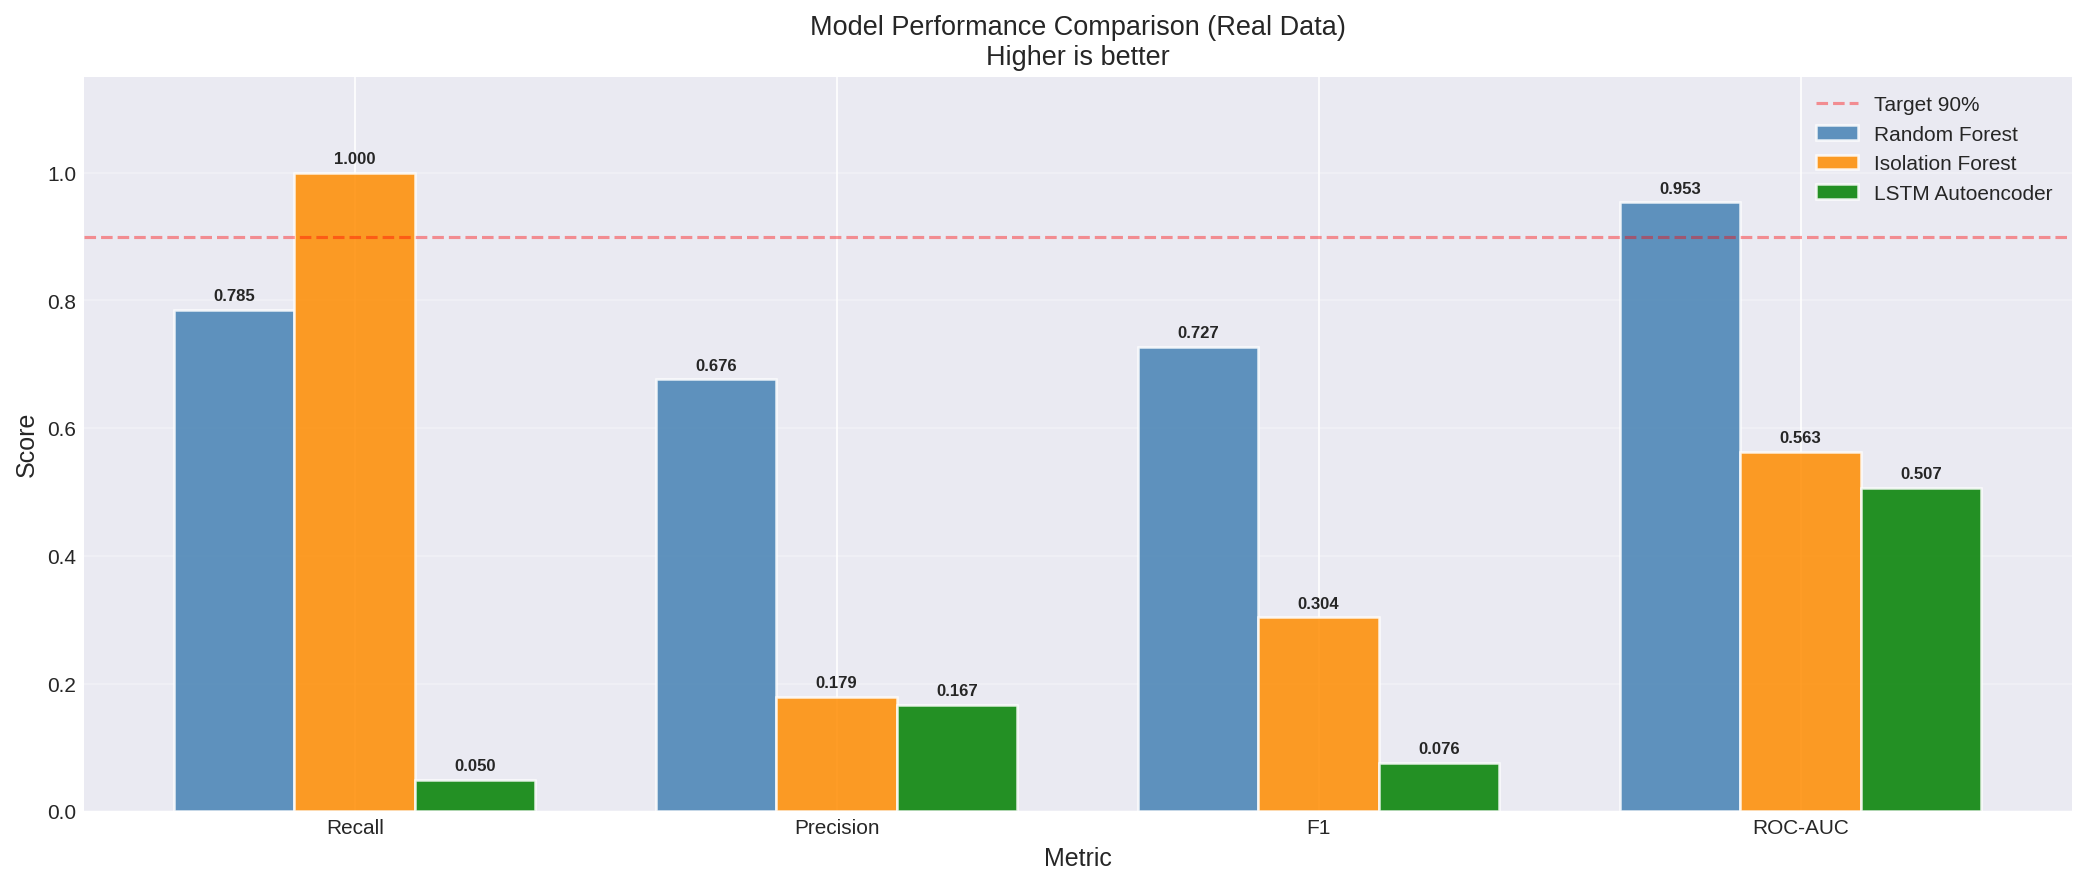

In [46]:
# ─── Bar chart comparison ─────────────────────────────────────────────────────
from IPython.display import Image, display

metrics     = ['Recall', 'Precision', 'F1', 'ROC-AUC']
model_names = comp['Model'].tolist()
colors      = ['steelblue', 'darkorange', 'green'][:len(model_names)]
x           = np.arange(len(metrics))
width       = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    row    = comp[comp['Model'] == name].iloc[0]
    values = [row[m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width,
                    label=name, color=color, alpha=0.85,
                    edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
data_src = '(Synthetic Data)' if USE_SYNTHETIC else '(Real Data)'
ax.set_title(f'Model Performance Comparison {data_src}\nHigher is better',
              fontsize=13)
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.4, label='Target 90%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'model_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
display(Image(filename=plot_path))
plt.show()

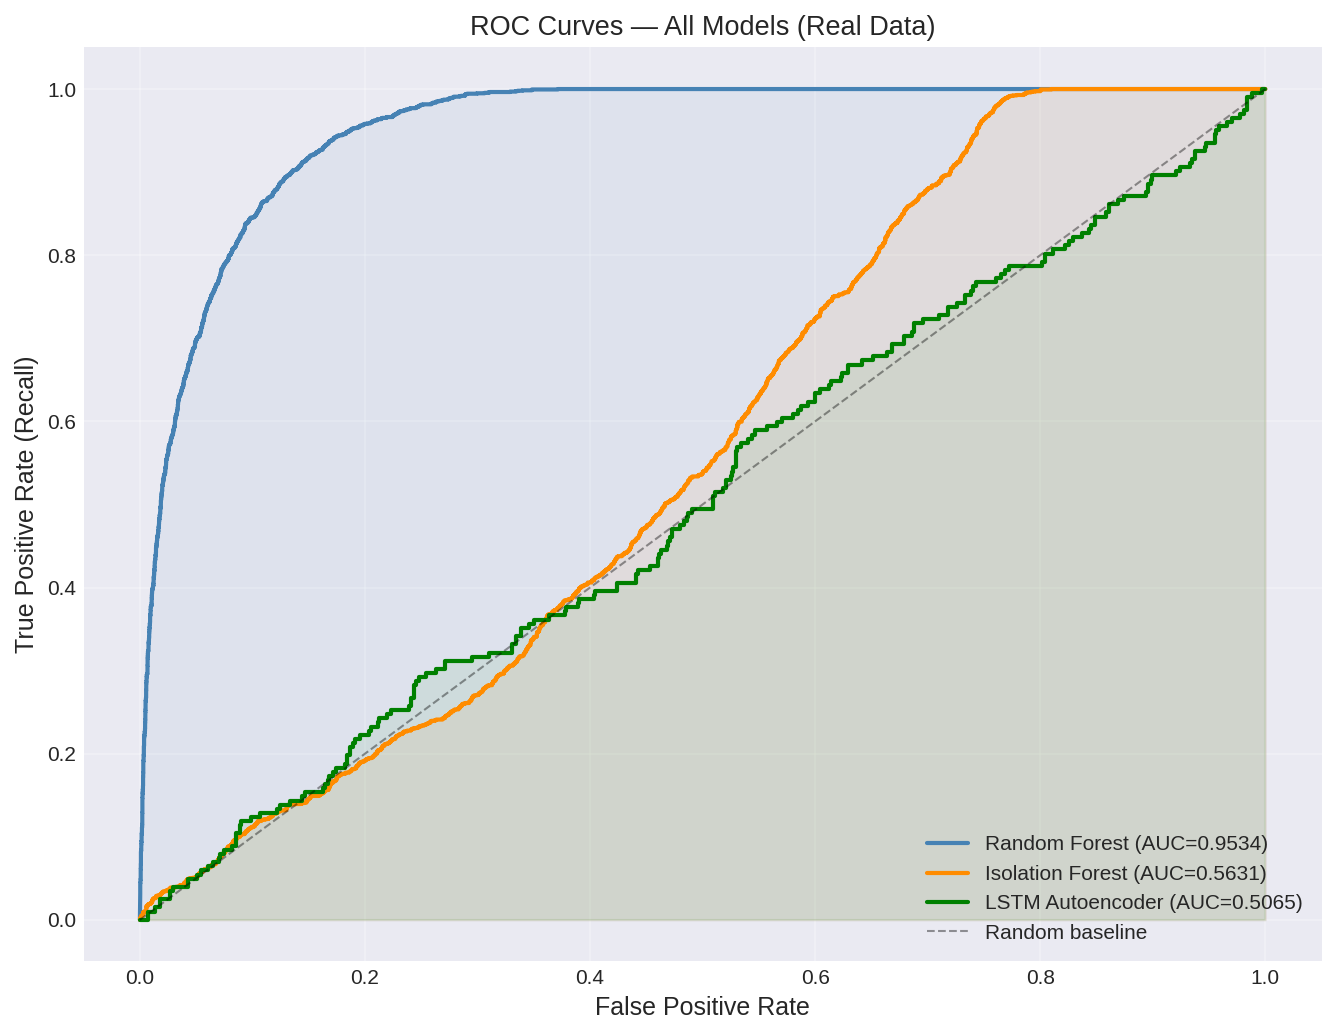

In [47]:
# ─── Combined ROC curves ──────────────────────────────────────────────────────
from IPython.display import Image, display
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))

# Helper: only plot ROC if test set has both classes
def safe_roc_plot(ax, y_true, y_score, label, color):
    if len(np.unique(y_true)) < 2:
        print(f'Skipping ROC for {label}: only one class in test set')
        return
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, color=color, label=label)
    ax.fill_between(fpr, tpr, alpha=0.07, color=color)

safe_roc_plot(ax,
    rf_results['y_test'], rf_results['test_proba'],
    f'Random Forest (AUC={rf_results["roc_auc"]:.4f})', 'steelblue')

safe_roc_plot(ax,
    if_results['y_test'], -if_results['test_scores'],
    f'Isolation Forest (AUC={if_results["roc_auc"]:.4f})', 'darkorange')

if TF_OK:
    safe_roc_plot(ax,
        lstm_results['y_test_seq'], lstm_results['test_errors'],
        f'LSTM Autoencoder (AUC={lstm_results["roc_auc"]:.4f})', 'green')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title(f'ROC Curves — All Models {data_src}', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'roc_curves_combined.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
display(Image(filename=plot_path))
plt.show()

## 7 — SystemEvent Translation Demo

In [29]:
print('=' * 60)
print('SYSTEMEVENT TRANSLATION DEMO')
print('Each model translates its output into a SystemEvent.')
print('The Mitigation System reads ONLY SystemEvents.')
print('=' * 60)

# Build a test feature snapshot with ransomware-like elevated values
test_feat = {col: float(X[col].mean()) for col in X.columns}

# Inject ransomware-like elevated signals
for col, val in [
    ('malfind.ninjections',     8.0),
    ('malfind.commitCharge',    6.0),
    ('ldrmodules.not_in_load',  5.0),
    ('psxview.not_in_pslist',   4.0),
    ('callbacks.ncallbacks',    3.0),
]:
    if col in test_feat:
        test_feat[col] = val

TEST_PID  = 4821
TEST_NAME = 'suspicious.exe'
print(f'\nSimulated process: PID={TEST_PID}, name={TEST_NAME}')
print('Feature snapshot has elevated ransomware-like values\n')

SYSTEMEVENT TRANSLATION DEMO
Each model translates its output into a SystemEvent.
The Mitigation System reads ONLY SystemEvents.

Simulated process: PID=4821, name=suspicious.exe
Feature snapshot has elevated ransomware-like values



In [30]:
# Random Forest → SystemEvent
e_rf = rf.predict(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print('RANDOM FOREST EVENT:')
print(e_rf)
print(f'  Alert      = {e_rf.alert}')
print(f'  Severity   = {e_rf.severity}')
print(f'  Confidence = {e_rf.confidence:.2%}')
print(f'  Actions    = {e_rf.recommended_actions}')
print()

RANDOM FOREST EVENT:
SystemEvent(🟢 NORMAL | NONE | source=RandomForest | pid=4821 | conf=9.97%)
  Alert      = False
  Severity   = NONE
  Confidence = 9.97%
  Actions    = ['no_action']



In [31]:
# Isolation Forest → SystemEvent
e_if = iso.predict(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print('ISOLATION FOREST EVENT:')
print(e_if)
print(f'  Alert        = {e_if.alert}')
print(f'  Anomaly Score= {e_if.anomaly_score:.4f}  (more negative = more anomalous)')
print(f'  Actions      = {e_if.recommended_actions}')
print()

ISOLATION FOREST EVENT:
SystemEvent(🔴 ALERT | MEDIUM | source=IsolationForest | pid=4821 | conf=47.80%)
  Alert        = True
  Anomaly Score= -0.4780  (more negative = more anomalous)
  Actions      = ['send_alert', 'log_event']



In [32]:
# Rule Engine → SystemEvent (simulating RULE-001: vssadmin delete shadows)
e_rule = make_rule_engine_event(
    pid              = TEST_PID,
    process_name     = 'cmd.exe',
    rule_id          = 'RULE-001',
    severity         = 'CRITICAL',
    response_actions = ['kill_process', 'send_alert', 'log_event'],
    features         = {'command': 'vssadmin delete shadows /all /quiet'},
    description      = 'Shadow copy deletion detected — RULE-001'
)
print('RULE ENGINE EVENT (RULE-001):')
print(e_rule)
print(f'  Confidence    = {e_rule.confidence:.2%}  (always 100% for CRITICAL rules)')
print(f'  Triggered Rule= {e_rule.triggered_rule}')
print()

import json
print('Full JSON output (for logging / storage):')
print(json.dumps(e_rule.to_dict(), indent=2))

RULE ENGINE EVENT (RULE-001):
SystemEvent(🔴 ALERT | CRITICAL | source=RuleEngine | pid=4821 | conf=100.00%)
  Confidence    = 100.00%  (always 100% for CRITICAL rules)
  Triggered Rule= RULE-001

Full JSON output (for logging / storage):
{
  "event_id": "8ea7dd84-313d-4fe7-aaf1-84c17f07b16d",
  "timestamp": 1776873807.048203,
  "pid": 4821,
  "process_name": "cmd.exe",
  "alert": true,
  "severity": "CRITICAL",
  "model_source": "RuleEngine",
  "confidence": 1.0,
  "triggered_rule": "RULE-001",
  "features": {
    "command": "vssadmin delete shadows /all /quiet"
  },
  "recommended_actions": [
    "kill_process",
    "send_alert",
    "log_event"
  ],
  "raw_prediction": 1,
  "anomaly_score": null,
  "description": "Shadow copy deletion detected \u2014 RULE-001"
}


## 8 — Next Steps: Getting Real Ransomware Data

### Why the metrics used synthetic data
Your 3 CSV files (`Output1.csv`, `output2.csv`, `output3.csv`) all contain **Spyware-TIBS** samples only.
The CIC-MalMem2022 dataset separates malware families into different files.
You need to download the **Ransomware** and **Benign** files.

### Option 1 — Download missing CIC-MalMem2022 files (recommended)
```
1. Go to: https://www.unb.ca/cic/datasets/malmem-2022.html
2. Download the CSV files for:
   - Ransomware families (WannaCry, Petya, Cerber, etc.)
   - Benign samples
3. Place them in: data/datasets/
4. Add their paths to CICMALMEM_PATHS in Section 2
5. Re-run this notebook — USE_SYNTHETIC will auto-set to False
```

### Option 2 — Use MalwareBazaar samples (advanced)
```
1. Download ransomware samples from: https://bazaar.abuse.ch
2. Run them in your Windows 10 VM (with Volatility3 for memory dumps)
3. Extract features using the same 55 feature names
4. Label them as Ransomware (1)
```

### When you get real data
The only change you need to make is:
```python
# In Section 2, add the new file paths:
CICMALMEM_PATHS = [
    ...,  # your existing paths
    os.path.join(PROJECT_ROOT, 'data', 'datasets', 'Ransomware_WannaCry.csv'),
    os.path.join(PROJECT_ROOT, 'data', 'datasets', 'Benign.csv'),
]
# Then Run All — everything else is automatic
```